In [1]:
# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
# Load Dataset

In [4]:
df = pd.read_csv("housing.csv")
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
# Data Cleaning

In [6]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
df = pd.get_dummies(df, columns=["ocean_proximity"])

In [7]:
# Data Visualization

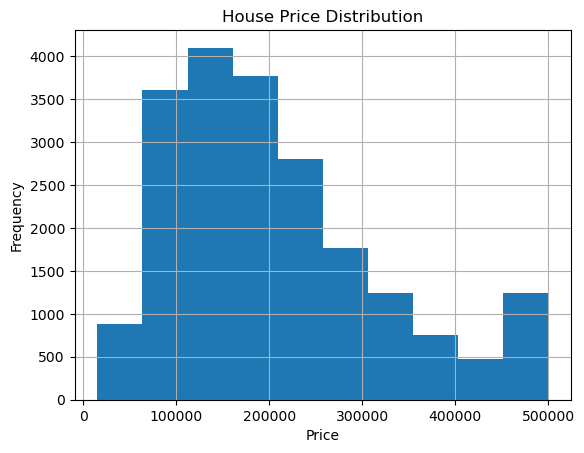

In [8]:
df["median_house_value"].hist()
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [9]:
# Feature Selection

In [11]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [12]:
# Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
# Model Training 

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [16]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [17]:
# Model Evaluation

In [18]:
print("Linear R2:", r2_score(y_test, y_pred_lr))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("MAE:", mae)
print("RMSE:", rmse)

Linear R2: 0.625424062055359
Random Forest R2: 0.8169411111174801
MAE: 31636.19363129845
RMSE: 48977.751228334


In [19]:
# Feature Importance

In [20]:
importance = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features)
print(feat_imp.sort_values(ascending=False).head(10))

median_income                 0.490642
ocean_proximity_INLAND        0.140925
longitude                     0.105889
latitude                      0.101597
housing_median_age            0.051935
population                    0.032573
total_bedrooms                0.023819
total_rooms                   0.023366
households                    0.018367
ocean_proximity_NEAR OCEAN    0.006336
dtype: float64


In [22]:
# Conclusion

# - Random Forest performed better than Linear Regression
# - Achieved R² score of ~0.81
# - Median income is the most important feature
# - Model can be improved further